# 04 — Feature Engineering

Builds the full feature set on top of `cleaned_data.csv`.

Note: X-Ray Background Flux was dropped during cleaning, so this notebook leans harder on momentum features (days since last M/X flare, trend ratios), lag features, and rolling sums of flare counts to compensate.

Order of operations:
1. Load data
2. Create targets FIRST (before any other feature, so leakage is easy to reason about)
3. Rolling sums for count columns
4. Days-since-last-flare
5. Cyclical / solar-cycle features
6. Log transforms
7. Momentum ratios
8. Lag features
9. Cleanup, leakage audit, save

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)

df = pd.read_csv('cleaned_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Rows: {len(df)}")
print(f"Date range: {df['Date'].min().date()}  ->  {df['Date'].max().date()}")
df.head()

Rows: 10068
Date range: 1999-01-27  ->  2026-08-20


,Date,Radio_Flux_10.7cm,SESC_Sunspot_Number,Sunspot_Area_10E-6_Hemis,New_Regions,Flares_C,Flares_M,Flares_X,Flares_S,Flares_1,Flares_2,Flares_3,Year,Radio_Flux_10.7cm_avg_3d,Radio_Flux_10.7cm_avg_7d,Radio_Flux_10.7cm_avg_27d,SESC_Sunspot_Number_avg_3d,SESC_Sunspot_Number_avg_7d,SESC_Sunspot_Number_avg_27d,Sunspot_Area_10E-6_Hemis_avg_3d,Sunspot_Area_10E-6_Hemis_avg_7d,Sunspot_Area_10E-6_Hemis_avg_27d
0,1999-01-27,125.0,64,70,1,3.0,0.0,0.0,0,0,1,0,1999,132.000000,153.857143,144.000000,64.000000,98.714286,102.370370,153.333333,518.571429,504.444444
1,1999-01-28,119.0,37,20,0,0.0,0.0,0.0,2,0,0,0,1999,125.666667,145.857143,142.222222,49.333333,84.857143,99.259259,63.333333,395.714286,473.333333
2,1999-01-29,118.0,33,30,0,1.0,0.0,0.0,2,0,0,0,1999,120.666667,137.285714,140.666667,44.666667,69.428571,96.518519,40.000000,254.285714,448.888889
3,1999-01-30,118.0,29,170,0,0.0,0.0,0.0,1,0,0,0,1999,118.333333,130.428571,139.296296,33.000000,56.857143,93.407407,73.333333,170.000000,430.370370
4,1999-01-31,115.0,59,210,2,0.0,0.0,0.0,2,0,0,0,1999,117.000000,123.714286,138.111111,40.333333,50.000000,92.111111,136.666667,127.142857,417.777778


In [8]:
print("Nulls per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else "None")

print("\nDuplicate dates:", df['Date'].duplicated().sum())

gap_days = df['Date'].diff().dt.days
print("Rows with a date gap > 1 day:", (gap_days > 1).sum())

Nulls per column:
None

Duplicate dates: 0
Rows with a date gap > 1 day: 0


## Targets First

Stage 1 target: binary — did an M or X class flare happen on day T+1?
Stage 2 target: count of M+X flares on day T+1.

Uses `.shift(-1)` so tomorrow's flare data lands on today's row. Last row has no "tomorrow", so it's dropped.

In [9]:
df['target_flare_MX_occurred'] = (
    (df['Flares_M'].shift(-1) > 0) | (df['Flares_X'].shift(-1) > 0)
).astype('Int64')

df['target_flare_MX_count'] = (
    df['Flares_M'].shift(-1) + df['Flares_X'].shift(-1)
)

df = df.iloc[:-1].reset_index(drop=True)

print(f"Rows after dropping last (no target): {len(df)}")
print(f"Stage 1 positive rate: {df['target_flare_MX_occurred'].mean():.2%}")
df[['Date', 'Flares_M', 'Flares_X', 'target_flare_MX_occurred', 'target_flare_MX_count']].head(10)

Rows after dropping last (no target): 10067
Stage 1 positive rate: 19.37%


,Date,Flares_M,Flares_X,target_flare_MX_occurred,target_flare_MX_count
0,1999-01-27,0.0,0.0,0,0.0
1,1999-01-28,0.0,0.0,0,0.0
2,1999-01-29,0.0,0.0,0,0.0
3,1999-01-30,0.0,0.0,0,0.0
4,1999-01-31,0.0,0.0,0,0.0
5,1999-02-01,0.0,0.0,0,0.0
6,1999-02-02,0.0,0.0,0,0.0
7,1999-02-03,0.0,0.0,0,0.0
8,1999-02-04,0.0,0.0,0,0.0
9,1999-02-05,0.0,0.0,0,0.0


In [10]:
# Leakage spot-check
check_idx = df[df['target_flare_MX_occurred'] == 1].index[0]
print("Row (today):")
print(df.loc[check_idx, ['Date','Flares_M','Flares_X','target_flare_MX_occurred','target_flare_MX_count']])
print("\nNext row (tomorrow) should match the target:")
print(df.loc[check_idx + 1, ['Date','Flares_M','Flares_X']])

Row (today):
Date                        1999-02-11 00:00:00
Flares_M                                    0.0
Flares_X                                    0.0
target_flare_MX_occurred                      1
target_flare_MX_count                       1.0
Name: 15, dtype: object

Next row (tomorrow) should match the target:
Date        1999-02-12 00:00:00
Flares_M                    1.0
Flares_X                    0.0
Name: 16, dtype: object


## Rolling Sums for Count-Type Columns

`New_Regions` and flare counts are sparse counts (mostly 0), so a rolling sum ("5 C-flares in 7 days") is more interpretable than a mean.

In [11]:
windows = [3, 7, 27]
count_cols = ['New_Regions', 'Flares_C', 'Flares_M', 'Flares_X',
              'Flares_S', 'Flares_1', 'Flares_2', 'Flares_3']

for col in count_cols:
    for w in windows:
        df[f'{col}_sum_{w}d'] = df[col].rolling(w).sum()

df[[c for c in df.columns if '_sum_' in c]].head()

,New_Regions_sum_3d,New_Regions_sum_7d,New_Regions_sum_27d,Flares_C_sum_3d,Flares_C_sum_7d,Flares_C_sum_27d,Flares_M_sum_3d,Flares_M_sum_7d,Flares_M_sum_27d,Flares_X_sum_3d,Flares_X_sum_7d,Flares_X_sum_27d,Flares_S_sum_3d,Flares_S_sum_7d,Flares_S_sum_27d,Flares_1_sum_3d,Flares_1_sum_7d,Flares_1_sum_27d,Flares_2_sum_3d,Flares_2_sum_7d,Flares_2_sum_27d,Flares_3_sum_3d,Flares_3_sum_7d,Flares_3_sum_27d
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,NaN,NaN,4.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,4.0,NaN,NaN,0.0,NaN,NaN,1.0,NaN,NaN,0.0,NaN,NaN
3,0.0,NaN,NaN,1.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,5.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN
4,2.0,NaN,NaN,1.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,5.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN


## Days Since Last M/X Flare

Active regions that produced a flare recently are more likely to produce another one soon. Rows before the first-ever M/X flare get a sentinel value (9999) instead of NaN.

In [12]:
def days_since_last_event(series: pd.Series) -> np.ndarray:
    vals = series.values
    out = np.full(len(vals), np.nan)
    last_event_idx = None
    for i, v in enumerate(vals):
        if v > 0:
            last_event_idx = i
            out[i] = 0
        elif last_event_idx is not None:
            out[i] = i - last_event_idx
    return out

df['days_since_last_M_flare'] = days_since_last_event(df['Flares_M'])
df['days_since_last_X_flare'] = days_since_last_event(df['Flares_X'])
df['days_since_last_MX_flare'] = days_since_last_event(df['Flares_M'] + df['Flares_X'])

for c in ['days_since_last_M_flare', 'days_since_last_X_flare', 'days_since_last_MX_flare']:
    df[c] = df[c].fillna(9999)

df[['Date','Flares_M','Flares_X','days_since_last_M_flare','days_since_last_X_flare']].head(10)

,Date,Flares_M,Flares_X,days_since_last_M_flare,days_since_last_X_flare
0,1999-01-27,0.0,0.0,9999.0,9999.0
1,1999-01-28,0.0,0.0,9999.0,9999.0
2,1999-01-29,0.0,0.0,9999.0,9999.0
3,1999-01-30,0.0,0.0,9999.0,9999.0
4,1999-01-31,0.0,0.0,9999.0,9999.0
5,1999-02-01,0.0,0.0,9999.0,9999.0
6,1999-02-02,0.0,0.0,9999.0,9999.0
7,1999-02-03,0.0,0.0,9999.0,9999.0
8,1999-02-04,0.0,0.0,9999.0,9999.0
9,1999-02-05,0.0,0.0,9999.0,9999.0


## Cyclical / Temporal Features

Annual seasonality via sin/cos of day-of-year, plus a piecewise 11-year solar cycle phase using approximate NOAA/SIDC solar minimum dates (cycle 26 start is a placeholder — update once officially finalized).

In [13]:
SOLAR_CYCLE_STARTS = {
    22: '1986-09-01',
    23: '1996-08-01',
    24: '2008-12-01',
    25: '2019-12-01',
    26: '2030-01-01',  # placeholder projection
}

doy = df['Date'].dt.dayofyear
df['day_of_year_sin'] = np.sin(2 * np.pi * doy / 365.25)
df['day_of_year_cos'] = np.cos(2 * np.pi * doy / 365.25)

starts = sorted((pd.Timestamp(v), k) for k, v in SOLAR_CYCLE_STARTS.items())

def cycle_phase(date):
    for i in range(len(starts) - 1):
        start_date, _ = starts[i]
        next_date, _ = starts[i + 1]
        if start_date <= date < next_date:
            total = (next_date - start_date).days
            elapsed = (date - start_date).days
            return elapsed / total
    return np.nan

df['solar_cycle_phase'] = df['Date'].apply(cycle_phase)
df['solar_cycle_phase_sin'] = np.sin(2 * np.pi * df['solar_cycle_phase'])
df['solar_cycle_phase_cos'] = np.cos(2 * np.pi * df['solar_cycle_phase'])

df[['Date','day_of_year_sin','day_of_year_cos','solar_cycle_phase']].head()

,Date,day_of_year_sin,day_of_year_cos,solar_cycle_phase
0,1999-01-27,0.447945,0.894061,0.201776
1,1999-01-28,0.463258,0.886224,0.201998
2,1999-01-29,0.478434,0.878124,0.202220
3,1999-01-30,0.493468,0.869764,0.202442
4,1999-01-31,0.508356,0.861147,0.202664


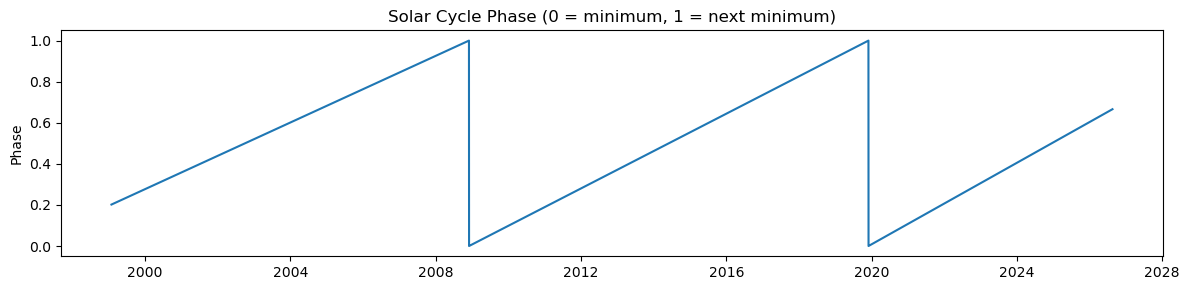

In [14]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(df['Date'], df['solar_cycle_phase'])
ax.set_title('Solar Cycle Phase (0 = minimum, 1 = next minimum)')
ax.set_ylabel('Phase')
plt.tight_layout()
plt.show()

## Log Transforms for Skewed Indices

Radio Flux and Sunspot Area are right-skewed. log1p compresses spikes while handling zero-valued days safely.

In [15]:
for col in ['Radio_Flux_10.7cm', 'SESC_Sunspot_Number', 'Sunspot_Area_10E-6_Hemis']:
    df[f'{col}_log'] = np.log1p(df[col])

df[[c for c in df.columns if c.endswith('_log')]].describe()

,Radio_Flux_10.7cm_log,SESC_Sunspot_Number_log,Sunspot_Area_10E-6_Hemis_log
count,10067.000000,10067.000000,10067.000000
mean,4.687736,3.465628,4.817778
std,0.362621,1.769402,2.523679
min,4.174387,0.000000,0.000000
25%,4.330733,2.708050,3.713572
50%,4.653960,4.094345,5.802118
75%,4.983607,4.779123,6.666957
max,5.820083,5.996452,8.646641


## Momentum / Ratio Features

Dividing today's value by its own 27-day average shows whether activity is spiking or receding relative to itself.

In [16]:
df['sunspot_num_vs_27d_avg'] = df['SESC_Sunspot_Number'] / (df['SESC_Sunspot_Number_avg_27d'] + 1)
df['radio_flux_vs_27d_avg'] = df['Radio_Flux_10.7cm'] / (df['Radio_Flux_10.7cm_avg_27d'] + 1)
df['sunspot_area_vs_27d_avg'] = df['Sunspot_Area_10E-6_Hemis'] / (df['Sunspot_Area_10E-6_Hemis_avg_27d'] + 1)

df['radio_flux_3d_vs_27d'] = df['Radio_Flux_10.7cm_avg_3d'] / (df['Radio_Flux_10.7cm_avg_27d'] + 1)
df['sunspot_num_3d_vs_27d'] = df['SESC_Sunspot_Number_avg_3d'] / (df['SESC_Sunspot_Number_avg_27d'] + 1)

df['new_regions_per_sunspot'] = df['New_Regions'] / (df['SESC_Sunspot_Number'] + 1)

df[['Date','sunspot_num_vs_27d_avg','radio_flux_3d_vs_27d','new_regions_per_sunspot']].head()

,Date,sunspot_num_vs_27d_avg,radio_flux_3d_vs_27d,new_regions_per_sunspot
0,1999-01-27,0.619133,0.910345,0.015385
1,1999-01-28,0.369043,0.877424,0.000000
2,1999-01-29,0.338397,0.851765,0.000000
3,1999-01-30,0.307179,0.843453,0.000000
4,1999-01-31,0.633652,0.841054,0.033333
